In [9]:
# Create a CSV summary from all Tucker log files in the specified directory

import os
import re
import glob
import pandas as pd

log_dir = "/data/users/ltucker/influenzaData/pipeline/log/tucker"
output_csv_path = "/data/users/ltucker/influenzaData/pipeline/output/tensor/tucker_log_summary.csv"

# Patterns to extract required fields
patterns = {
    "Ratio": r"Ratio:\s*'([^']+)'",
    "Percentage": r"Percentage:\s*'([^']+)'",
    "Iteration": r"Iteration:\s*'([^']+)'",
    "Seed": r"Seed:\s*'([^']+)'",
    "Core_tensor_shape": r"Core tensor shape:\s*\(([^)]+)\)",
    "Factor0_shape": r"Factor 0 .* shape:\s*\(([^)]+)\)",
    "Factor1_shape": r"Factor 1 .* shape:\s*\(([^)]+)\)",
    "Factor2_shape": r"Factor 2 .* shape:\s*\(([^)]+)\)",
    "Rank": r"Rank:\s*\[([^\]]+)\]",
    "Relative_Error": r"Relative Error:\s*([0-9.]+)",
    "Fit_Score": r"Fit Score .*:\s*([0-9.]+)",
    "Explained_Variance": r"Explained Variance:\s*([0-9.]+)",
    "Compression_Ratio": r"Compression Ratio:\s*([0-9.]+)x"
}

rows = []

# Find all .log files
log_files = glob.glob(os.path.join(log_dir, "*.log"))

for log_file in log_files:
    with open(log_file, "r") as f:
        content = f.read()
    
    row = {"log_file": os.path.basename(log_file)}
    
    for key, pattern in patterns.items():
        match = re.search(pattern, content)
        row[key] = match.group(1).strip() if match else None
    
    rows.append(row)

# Create DataFrame
df = pd.DataFrame(rows)

# Save to CSV
#df.to_csv(output_csv_path, index=False)

output_csv_path; df[df["Core_tensor_shape"] == "2, 3, 3"].sort_values(by="Ratio")


,log_file,Ratio,Percentage,Iteration,Seed,Core_tensor_shape,Factor0_shape,Factor1_shape,Factor2_shape,Rank,Relative_Error,Fit_Score,Explained_Variance,Compression_Ratio
2,tucker_16349932_4.log,0.05,5,4,4,"2, 3, 3","8, 2","1116, 3","1116, 3","2, 3, 3",0.260874,0.739126,0.931945,1480.48
51,tucker_16349932_1.log,0.05,5,1,1,"2, 3, 3","8, 2","1116, 3","1116, 3","2, 3, 3",0.269285,0.730715,0.927485,1480.48
44,tucker_16349932_3.log,0.05,5,3,3,"2, 3, 3","8, 2","1116, 3","1116, 3","2, 3, 3",0.265613,0.734387,0.929450,1480.48
39,tucker_16349932_2.log,0.05,5,2,2,"2, 3, 3","8, 2","1116, 3","1116, 3","2, 3, 3",0.263311,0.736689,0.930668,1480.48
19,tucker_16349932_0.log,0.05,5,0,0,"2, 3, 3","8, 2","1116, 3","1116, 3","2, 3, 3",0.279549,0.720451,0.921852,1480.48
22,tucker_16349932_8.log,0.1,10,3,1003,"2, 3, 3","8, 2","2233, 3","2233, 3","2, 3, 3",0.264524,0.735476,0.930027,2969.80
48,tucker_16349932_5.log,0.1,10,0,1000,"2, 3, 3","8, 2","2233, 3","2233, 3","2, 3, 3",0.261312,0.738688,0.931716,2969.80
18,tucker_16349932_7.log,0.1,10,2,1002,"2, 3, 3","8, 2","2233, 3","2233, 3","2, 3, 3",0.276237,0.723763,0.923693,2969.80
56,tucker_16349932_9.log,0.1,10,4,1004,"2, 3, 3","8, 2","2233, 3","2233, 3","2, 3, 3",0.267565,0.732435,0.928409,2969.80
13,tucker_16349932_6.log,0.1,10,1,1001,"2, 3, 3","8, 2","2233, 3","2233, 3","2, 3, 3",0.263421,0.736579,0.930609,2969.80


In [59]:
df_233 = df[df["Core_tensor_shape"] == "2, 3, 3"].sort_values(by="Ratio")
for col in ("Relative_Error", "Fit_Score", "Explained_Variance", "Compression_Ratio"):
    df_233[col] = pd.to_numeric(df_233[col], errors="coerce")
    mean = df_233[col].mean()
    sem = df_233[col].sem()
    print(f'{col} : {mean:.6f} ± {sem:.6f}')

print("\n")

df_122 = df[df["Core_tensor_shape"] == "1, 2, 2"].sort_values(by="Ratio")
for col in ("Relative_Error", "Fit_Score", "Explained_Variance", "Compression_Ratio"):
    df_122[col] = pd.to_numeric(df_122[col], errors="coerce")
    mean = df_122[col].mean()
    sem = df_122[col].sem()
    print(f'{col} : {mean:.6f} ± {sem:.6f}')


Relative_Error : 0.268877 ± 0.000913
Fit_Score : 0.731123 ± 0.000913
Explained_Variance : 0.927683 ± 0.000493
Compression_Ratio : 8649.692593 ± 1443.808247


Relative_Error : 0.344276 ± 0.000671
Fit_Score : 0.655724 ± 0.000671
Explained_Variance : 0.881462 ± 0.000463
Compression_Ratio : 12979.857407 ± 2165.714049


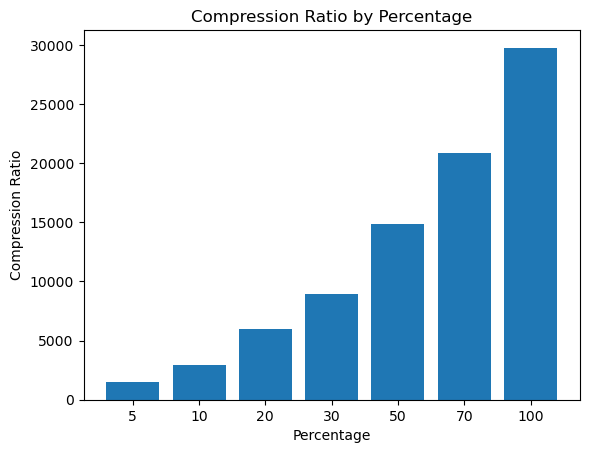

In [61]:
df_233 = df[df["Core_tensor_shape"] == "2, 3, 3"].sort_values(by="Ratio")
df_233
import matplotlib.pyplot as plt
import numpy as np

plt.bar(df_233["Percentage"], df_233["Compression_Ratio"])
plt.xlabel("Percentage")
plt.ylabel("Compression Ratio")
#plt.ylim(0, 1)
#plt.yticks(np.arange(0, 1.1, 0.1))
plt.title("Compression Ratio by Percentage")
plt.show()

In [33]:
print(df_233["Percentage"].head())
print(df_233["Percentage"].dtype)
print(df_233[["Percentage", "Fit_Score"]].isna().sum())

2     5
51    5
44    5
39    5
19    5
Name: Percentage, dtype: object
object
Percentage    0
Fit_Score     0
dtype: int64


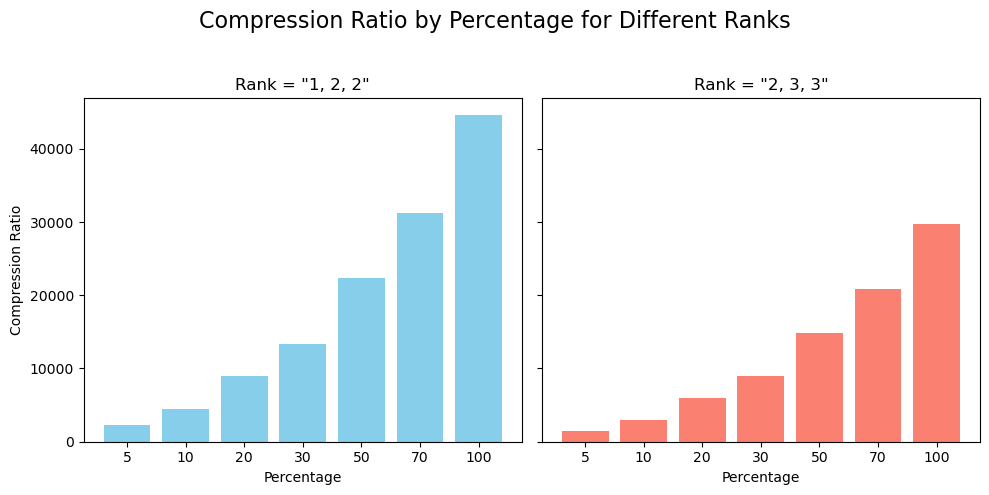

In [71]:
import matplotlib.pyplot as plt
import numpy as np

# Filter data for each rank
df_rank_122 = df[df["Rank"] == "1, 2, 2"].sort_values(by="Ratio")
df_rank_233 = df[df["Rank"] == "2, 3, 3"].sort_values(by="Ratio")

# Create side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)  # sharey=True keeps the y-axis the same

# Plot Rank = "1,2,2"
axes[0].bar(df_rank_122["Percentage"], df_rank_122["Compression_Ratio"], color='skyblue')
axes[0].set_xlabel("Percentage")
axes[0].set_ylabel("Compression Ratio")
axes[0].set_title('Rank = "1, 2, 2"')

# Plot Rank = "1,3,3"
axes[1].bar(df_rank_233["Percentage"], df_rank_233["Compression_Ratio"], color='salmon')
axes[1].set_xlabel("Percentage")
axes[1].set_title('Rank = "2, 3, 3"')

# Optional: set y-axis limit and ticks
# axes[0].set_ylim(0, 1)
# axes[0].set_yticks(np.arange(0, 1.1, 0.1))

plt.suptitle("Compression Ratio by Percentage for Different Ranks", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # adjust layout to fit suptitle
plt.show()